## **UNSUPERVISED LEARNING**

In [95]:
import pandas as pd               
import matplotlib.pyplot as plt   
import seaborn as sns             
%matplotlib inline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
import warnings
warnings.filterwarnings('ignore')

In [96]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [97]:
missing_values = df.isnull().sum()
print("Missing values in each column: ")
print(missing_values)

Missing values in each column: 
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [98]:
duplicate_values = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_values)

Number of duplicate rows: 0


In [99]:
# These features are most relevant for customer segmentation
df.rename(columns={'Annual Income (k$)': 'Income(k$/yr)', 'Spending Score (1-100)': 'SpendScore(1-100)'}, inplace=True)
df = df.drop(columns=['CustomerID'])

## **Data preparation and standardization**

In [100]:
X = df[['Income(k$/yr)', 'SpendScore(1-100)']]
scaler = StandardScaler()
X_kmeans = scaler.fit_transform(X)

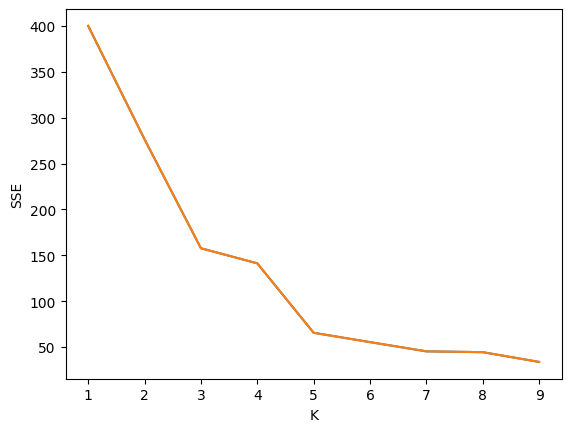

In [101]:
# Elbow method for determining the number of clusters
sse = []
k_range = range(1,10)
for cluster in k_range:
    kmeans = KMeans(n_clusters=cluster)
    kmeans.fit(X_kmeans)
    sse.append(kmeans.inertia_)

plt.plot(k_range, sse)
plt.xlabel('K')
plt.ylabel('SSE')
plt.plot(k_range, sse)
plt.show()

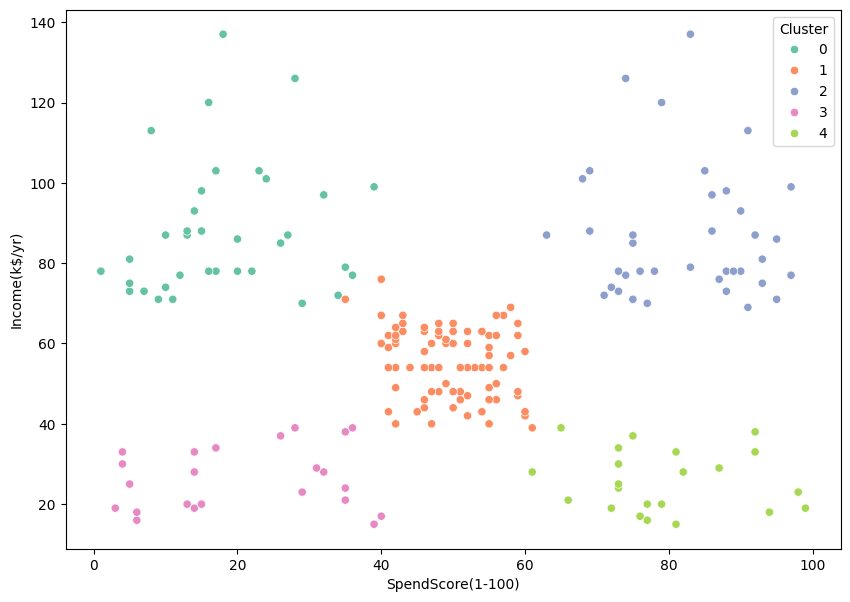

In [113]:
# KMeans with 5 clusters and visualization
# We use a scatter plot to visualize the clusters formed
plt.figure(figsize=(10, 7))
clusters = KMeans(n_clusters=5)
y_kmeans = clusters.fit_predict(X_kmeans)
df['Cluster'] = y_kmeans
sns.scatterplot(data=df, x='SpendScore(1-100)', y='Income(k$/yr)', hue='Cluster', palette="Set2")
plt.show()